In [70]:
import pandas as pd
import feature_engineering_helper as hf
import pickle

In [71]:
import feature_engineering_helper as hf
print(hf.__file__)

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py


In [61]:
### change this to 1 for quick test, 0 for full run
quick_test = 0
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=20
    num_feat_binary_interaction = 20
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    num_feat_binary_interaction = 20
    print("Full run mode")



Full run mode


In [72]:
data_prefix = '../data_curation/processed_data/'

if quick_test == 1:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features_RDKit_60_MW.parquet').head(500)
else:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features_RDKit_60_MW.parquet')

df_all_feature

,MP,MW_label,RDKit_AvgIpc,RDKit_BCUT2D_CHGHI,RDKit_BCUT2D_CHGLO,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_LOGPLOW,RDKit_BCUT2D_MRHI,RDKit_BCUT2D_MRLOW,RDKit_BCUT2D_MWHI,...,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,SMILES,Type
0,140.0,1,2.940007,2.112551,-1.984418,2.244289,-2.052986,6.301636,-0.137429,35.495691,...,0,0,0,0,0,0,0,0.484929,CCOC(=O)/C(=C/c1ccc(o1)c1ccc(cc1)Cl)/C#N,Train
1,249.0,0,2.065242,1.961070,-1.948790,2.149991,-2.031881,9.103018,1.275854,79.918731,...,0,0,0,0,0,0,0,0.731061,Brc1ccc2c(c1)c(=O)[nH]cc2,Train
2,239.0,0,2.336813,2.102505,-1.996622,2.082950,-2.140634,5.964214,0.100077,16.251448,...,0,0,0,0,0,0,0,0.515733,Nc1c(cnn1CCO)C(=O)N,Train
3,145.0,0,1.650022,1.922885,-1.885944,1.657912,-2.115374,5.548647,-0.115975,16.322700,...,0,0,0,0,0,0,0,0.407217,OC(C=O)CO,Train
4,273.0,1,2.863790,2.946267,-2.675893,2.917635,-2.779698,9.104514,-0.163990,79.919762,...,0,0,0,0,0,0,0,0.209231,CCOC(=O)C12C(c3cc(Br)ccc3O[P@@]2(=O)OCC)C2(C1c...,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,16.0,0,1.910086,2.069604,-2.245572,2.063583,-2.314919,4.624201,0.173049,16.251357,...,0,0,0,0,0,0,0,0.585383,OCCN1CCCCC1,Test
17216,357.0,1,2.467837,2.202914,-2.088634,2.415048,-2.025272,5.879681,0.367564,16.360874,...,0,0,0,0,0,0,0,0.370750,Oc1cc(O)c2c(c1)oc(c(c2=O)O)c1cc(O)c(c(c1)O)O,Test
17217,143.0,0,1.941518,2.061016,-1.955382,2.236206,-1.903168,5.567510,-0.384390,16.628251,...,0,0,0,0,0,0,0,0.271725,[O-][N+](=O)c1ccc(c(c1)N)O,Test
17218,240.0,1,3.049813,2.314510,-2.110938,2.268347,-2.307311,9.103016,-0.113797,79.918731,...,0,0,0,0,0,0,0,0.543579,Brc1cccc(c1)N/N=C/1\C(=O)NN=C1c1c(O)c2ccccc2n(...,Test


In [73]:
data_with_features_train = df_all_feature[df_all_feature['Type'] == 'Train']
print(data_with_features_train.shape)

data_with_features_train.describe()

(10332, 221)


,MP,MW_label,RDKit_AvgIpc,RDKit_BCUT2D_CHGHI,RDKit_BCUT2D_CHGLO,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_LOGPLOW,RDKit_BCUT2D_MRHI,RDKit_BCUT2D_MRLOW,RDKit_BCUT2D_MWHI,...,RDKit_fr_sulfonamd,RDKit_fr_sulfone,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed
count,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,...,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000
mean,126.102717,0.263163,2.338074,2.170308,-2.102757,2.239246,-2.120896,6.523166,0.189402,27.947905,...,0.021293,0.010840,0.006098,0.003194,0.017034,0.000774,0.017422,0.392180,0.020712,0.584908
std,70.917833,0.440371,0.429686,0.216290,0.183883,0.193159,0.248627,1.499124,0.529909,21.665338,...,0.159042,0.105408,0.087234,0.056428,0.130893,0.034073,0.142866,2.240001,0.145785,0.164431
min,0.000000,0.000000,0.000000,-0.411510,-2.751901,-0.289300,-2.996005,0.823800,-1.112994,13.457632,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.034615
25%,69.000000,0.000000,2.035589,2.023127,-2.196052,2.133633,-2.298949,5.756742,-0.138758,16.365139,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.483987
50%,121.000000,0.000000,2.298768,2.131318,-2.062106,2.232907,-2.091331,5.989187,0.069186,16.628308,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.598064
75%,175.000000,1.000000,2.619577,2.291613,-1.987202,2.334520,-1.934916,6.651567,0.414539,32.452992,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.704464
max,492.500000,1.000000,3.948782,3.066522,-0.411510,2.951022,-0.114300,15.020000,13.020000,127.904000,...,2.000000,2.000000,4.000000,1.000000,2.000000,2.000000,3.000000,36.000000,2.000000,0.945893


In [74]:
def feature_engineering_workflow(data_type):
    tolerance = 0.01

    all_feature_cols = data_with_features_train.drop(
        columns=['SMILES', 'MP', 'Type', 'MW_label'], axis=1
    ).columns.tolist()

    if data_type == 'Low MW':
        data = data_with_features_train[data_with_features_train['MW_label'] == 0].reset_index(drop=True)
    elif data_type == 'High MW':
        data = data_with_features_train[data_with_features_train['MW_label'] == 1].reset_index(drop=True)
    else:
        raise ValueError("data_type must be 'Low MW' or 'High MW'")

    df_X_scaled = hf.standardize_features(
        data=data,
        all_feature_cols=all_feature_cols,
        scaler_path=data_prefix + f'scaler_{data_type}.pkl',
        fit=True
    )

    df_X_variance = hf.reduce_features_by_variance(df_X_scaled, variance_threshold=0.01)

    def RFE_workflow(X, round):
        RFE_results = hf.reduce_features_by_RFE(
            X, data['MP'],
            tolerance=tolerance,
            n_features_to_select=n_features_to_select,
            step=step,
            metric='rmse',
            cv_strategy=None
        )
        hf.RFE_plot(RFE_results, tolerance)
        with open(data_prefix + f'RFE_results_{data_type}_{round}.pkl', 'wb') as f:
            pickle.dump(RFE_results, f)

        df_X_RFE = X[RFE_results['best_features']]
        return df_X_RFE, RFE_results

    df_X_final, RFE_results_1 = RFE_workflow(df_X_variance, 1)

    return df_X_scaled, df_X_variance, RFE_results_1, df_X_final

✓ Scaler saved to: ../data_curation/processed_data/scaler_Low MW.pkl
✓ Standardization complete. Shape: (7613, 217)
Original features: 217
Removed features: 5
Remaining features: 212


RFE Feature Selection:   2%|▏         | 1/43 iteration

Iteration 0/43 | Features: 207 | RMSE: 37.6264 ± 1.0854 | Removed: [RDKit_HeavyAtomCount, RDKit_fr_dihydropyridine, RDKit_fr_epoxide, RDKit_fr_guanido, RDKit_fr_ketone]


RFE Feature Selection:  26%|██▌       | 11/43 iteration

Iteration 10/43 | Features: 157 | RMSE: 37.6985 ± 1.0553 | Removed: [RDKit_AvgIpc, RDKit_ExactMolWt, RDKit_NumAliphaticHeterocycles, RDKit_fr_C_O, RDKit_fr_tetrazole]


...

Iteration 30/43 | Features: 57 | RMSE: 37.5761 ± 1.2528 | Removed: [RDKit_FpDensityMorgan2, RDKit_HallKierAlpha, RDKit_PEOE_VSA11, RDKit_PEOE_VSA3, RDKit_Phi]


RFE Feature Selection:  95%|█████████▌| 41/43 iteration

Iteration 40/43 | Features: 7 | RMSE: 45.9017 ± 1.0164 | Removed: [RDKit_NHOHCount, RDKit_fr_ArN, RDKit_fr_Ar_NH, RDKit_fr_Ar_OH, RDKit_fr_COO]


RFE Feature Selection: 100%|██████████| 43/43 iteration



Global best RMSE: 37.4002
Threshold (1.0% tolerance): 37.7742

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 47
  Selected RMSE: 37.6056
  Best features (Top 5): ['RDKit_NumHDonors', 'RDKit_TPSA', 'RDKit_RingCount', 'RDKit_fr_Ar_COO', 'RDKit_fr_bicyclic']


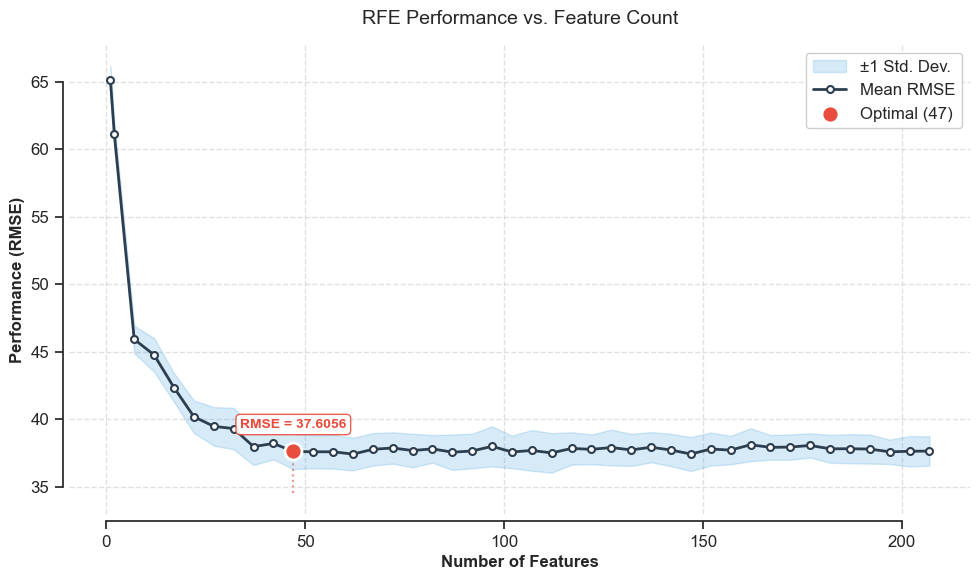

  Optimal Feature Set: 47 features
  Best RMSE: 37.6056


In [75]:
df_Ro5_X_scaled, df_Ro5_X_variance, RFE_results_Ro5_1, df_Ro5_X_final = feature_engineering_workflow('Low MW')

✓ Scaler saved to: ../data_curation/processed_data/scaler_High MW.pkl
✓ Standardization complete. Shape: (2719, 217)
Original features: 217
Removed features: 8
Remaining features: 209


RFE Feature Selection:   2%|▏         | 1/42 iteration

Iteration 0/42 | Features: 204 | RMSE: 43.2089 ± 2.4047 | Removed: [RDKit_MaxEStateIndex, RDKit_fr_SH, RDKit_fr_guanido, RDKit_fr_nitroso, RDKit_fr_oxazole]


RFE Feature Selection:  26%|██▌       | 11/42 iteration

Iteration 10/42 | Features: 154 | RMSE: 43.4389 ± 2.0458 | Removed: [RDKit_HeavyAtomCount, RDKit_NumAromaticCarbocycles, RDKit_NumBridgeheadAtoms, RDKit_fr_dihydropyridine, RDKit_fr_term_acetylene]


...

Iteration 30/42 | Features: 54 | RMSE: 42.7401 ± 2.4958 | Removed: [RDKit_PEOE_VSA10, RDKit_PEOE_VSA6, RDKit_SMR_VSA7, RDKit_SlogP_VSA6, RDKit_VSA_EState8]


RFE Feature Selection:  98%|█████████▊| 41/42 iteration

Iteration 40/42 | Features: 4 | RMSE: 54.6977 ± 3.0261 | Removed: [RDKit_NumRotatableBonds, RDKit_SlogP_VSA8, RDKit_TPSA, RDKit_fr_NH1, RDKit_fr_allylic_oxid]


RFE Feature Selection: 100%|██████████| 42/42 iteration



Global best RMSE: 42.6332
Threshold (1.0% tolerance): 43.0595

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 44
  Selected RMSE: 42.7562
  Best features (Top 5): ['RDKit_RingCount', 'RDKit_fr_unbrch_alkane', 'RDKit_NHOHCount', 'RDKit_NumRotatableBonds', 'RDKit_fr_bicyclic']


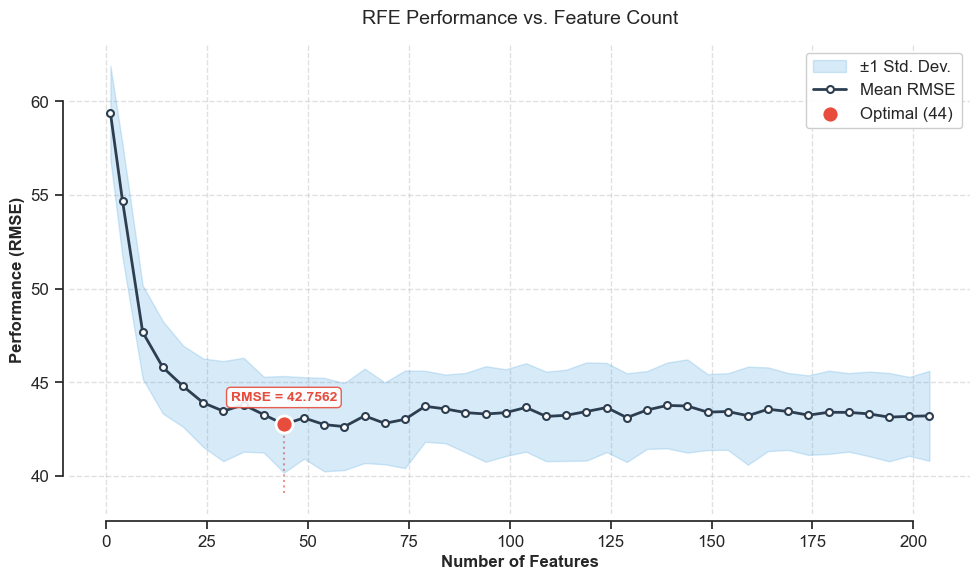

  Optimal Feature Set: 44 features
  Best RMSE: 42.7562


In [76]:
df_H_X_scaled, df_H_X_variance, RFE_results_bRo5_1, df_bRo5_X_final = feature_engineering_workflow('High MW')

In [77]:
selected_features = hf.combine_features(df_Ro5_X_final, df_bRo5_X_final)

with open(data_prefix + 'selected_feature_list_RDKit_60_MW.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

with open(data_prefix + 'selected_feature_list_RDKit_60_MW.pkl', 'rb') as f:
    selected_features = pickle.load(f)

print(selected_features)
print(len(selected_features))

Number of features in Ro5 dataset: 47
Number of features in bRo5 dataset: 44
Number of overlapping features: 26
Overlapping features: {'RDKit_SlogP_VSA8', 'RDKit_Kappa3', 'RDKit_RingCount', 'RDKit_SMR_VSA5', 'RDKit_FractionCSP3', 'RDKit_MaxPartialCharge', 'RDKit_fr_Ar_NH', 'RDKit_PEOE_VSA9', 'RDKit_VSA_EState1', 'RDKit_fr_bicyclic', 'RDKit_PEOE_VSA2', 'RDKit_NumAmideBonds', 'RDKit_SMR_VSA4', 'RDKit_fr_NH1', 'RDKit_SlogP_VSA1', 'RDKit_fr_Ar_COO', 'RDKit_NumRotatableBonds', 'RDKit_fr_unbrch_alkane', 'RDKit_TPSA', 'RDKit_SMR_VSA10', 'RDKit_VSA_EState3', 'RDKit_MinAbsPartialCharge', 'RDKit_NHOHCount', 'RDKit_VSA_EState2', 'RDKit_SlogP_VSA2', 'RDKit_BertzCT'}
Total number of combined features: 65
['RDKit_SlogP_VSA8', 'RDKit_NumHeteroatoms', 'RDKit_PEOE_VSA7', 'RDKit_Phi', 'RDKit_VSA_EState6', 'RDKit_MaxPartialCharge', 'RDKit_fr_Ar_NH', 'RDKit_fr_aniline', 'RDKit_PEOE_VSA12', 'RDKit_FpDensityMorgan2', 'RDKit_fr_ether', 'RDKit_NumAtomStereoCenters', 'RDKit_NumAmideBonds', 'RDKit_VSA_EState5',

In [79]:
data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features_RDKit_60_MW.parquet')
df_final = hf.dataset_featurization(data_with_features, selected_features, data_prefix + 'final_dataset_RDKit_60_MW')


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is high

✓ RDKit: Added 217 features


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

✓ MACCS: Added 167 features
Generating 73536 interaction features from 384 features...


KeyError: "['Ro5'] not in index"

In [ ]:
df_final = pd.read_parquet(data_prefix + 'final_dataset_RDKit_60_MW.parquet')

df_final_scaled = hf.standardize_data(df_final, data_prefix + 'df_final_scaler_RDKit_60_MW.pkl')


Number of feature columns to standardize: 72
Scaler saved to ../data_curation/processed_data/df_final_scaler_RDKit_50_threshold_0.pkl


In [ ]:
import joblib


data_path = "../data_curation/processed_data/final_dataset_RDKit_60_MW.parquet"
scaler_path = "../data_curation/processed_data/df_final_scaler_RDKit_60_MW.pkl"
output_path = "../Ro5/artifacts/final_dataset_RDKit_60_MW_scaled.parquet"


df_final = pd.read_parquet(data_path)


non_feature_cols = ["SMILES", "MP", "Type", "MW_label"] 
feature_cols = [c for c in df_final.columns if c not in non_feature_cols]



scaler = joblib.load(scaler_path)   # Load saved scaler


# Transform features (NO FITTING)

X_scaled = scaler.transform(df_final[feature_cols]) # Transform features (NO FITTING)

# Replace feature columns with scaled values
df_final_scaled = df_final.copy()
df_final_scaled[feature_cols] = X_scaled

# -------------------------
# Save as parquet
# -------------------------
df_final_scaled.to_parquet(output_path, index=False)

print("Scaled dataset saved to:", output_path)


Scaled dataset saved to: ../Ro5/artifacts/final_dataset_RDKit_50_threshold_0_scaled.parquet


In [ ]:
df = pd.read_parquet("../Ro5/artifacts/final_dataset_RDKit_60_MW_scaled.parquet")
df.head()

,SMILES,MP,Type,Ro5,RDKit_SlogP_VSA8,RDKit_NumHeteroatoms,RDKit_PEOE_VSA7,RDKit_Phi,RDKit_VSA_EState6,RDKit_MaxPartialCharge,...,RDKit_fr_priamide,RDKit_NumAliphaticRings,RDKit_fr_quatN,RDKit_fr_COO,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_SlogP_VSA4,RDKit_fr_allylic_oxid,RDKit_NHOHCount,RDKit_fr_ArN
0,c1ccc(cc1)n1cncc1,13.00,Train,1,0.382336,-0.882978,-0.693833,-0.772773,0.378189,-1.132235,...,-0.156889,-0.506106,-0.037112,-0.360850,-0.536894,-0.306271,-0.656439,-0.209052,-0.862968,-0.270778
1,Fc1cccc(c1c1noc(c1C(=O)O)C)Cl,202.00,Train,1,1.210742,0.598113,-0.348357,-0.319828,-0.444076,0.879647,...,-0.156889,-0.506106,-0.037112,2.103004,-0.137966,-0.306271,0.656088,-0.209052,-0.074623,-0.270778
2,c1ccc2c(c1)non2,54.00,Train,1,1.177431,-0.512705,-0.179225,-0.989164,0.023560,-0.836178,...,-0.156889,-0.506106,-0.037112,-0.360850,-0.491383,-0.306271,-0.656439,-0.209052,-0.862968,-0.270778
3,Cc1ccn[nH]c1=O,153.85,Train,1,-0.463529,-0.512705,-0.651052,-0.878915,-0.769099,0.259721,...,-0.156889,-0.506106,-0.037112,-0.360850,-0.498306,-0.306271,0.056819,-0.209052,-0.074623,-0.270778
4,OCC12CCCC(C1CC(C13C2C(O)CC(C1O)C(C3=O)C)O)(C)CO,266.00,Train,1,-0.463529,0.598113,0.843072,0.099328,-0.995496,-0.731595,...,-0.156889,3.270771,-0.037112,-0.360850,2.644924,-0.306271,3.455622,-0.209052,3.078757,-0.270778
